# Stochastic AdaBoost — Multiclass Classification (Stagewise Additive Modeling Multi-class Exponential loss with Real-valued Predictions :- SAMME.R)

---

## 1. Problem Setup

Assume we have a dataset

$$
\{(x_i, y_i)\}_{i=1}^{N}
$$

where

$$
x_i \in \mathbb{R}^D
$$

and

$$
y_i \in \{0,1,2,\dots,K-1\}
$$

The goal is to learn a classifier that combines multiple weak learners using probability outputs.

---

## 2. Model Idea

SAMME.R builds an additive model over class scores:

$$
F_k(x) = \sum_{m=1}^{M} f_k^{(m)}(x)
$$

Final probabilities are obtained using softmax:

$$
P(y = k \mid x) = \frac{\exp(F_k(x))}{\sum_{j=1}^{K} \exp(F_j(x))}
$$

---

## 3. Initialization

Initialize uniform weights:

$$
w_i^{(1)} = \frac{1}{N}
$$

In practice, weights are maintained in log-space:

$$
\log w_i^{(1)} = \log\left(\frac{1}{N}\right)
$$

---

## 4. Weighted Sampling (Stochastic Boosting)

At each iteration:

$$
\mathcal{D}^{(m)} \sim \text{Multinomial}(w^{(m)})
$$

---

## 5. Weak Learner

Train a probabilistic classifier:

$$
h_m(x) \rightarrow p_k^{(m)}(x) = P(y = k \mid x)
$$

---

## 6. Class Score Function
In SAMME.R, the weak learner outputs class probabilities, which are transformed into class-wise scores. This transformation ensures that the contributions are centered and comparable across classes, improving stability of the additive model.

$$
f_k^{(m)}(x) = (K - 1)\left(\log p_k^{(m)}(x) - \frac{1}{K} \sum_{j=1}^{K} \log p_j^{(m)}(x)\right)
$$

---

## 7. Additive Model Update

In SAMME.R, each weak learner is added to the ensemble in a stagewise manner. The learning rate $\eta$ controls how much each learner contributes, helping to stabilize training and reduce sensitivity to noisy learners.


$$
F_k(x) \leftarrow F_k(x) + \eta \, f_k^{(m)}(x)
$$

---

## 8. Weight Update with learning rate
Sample weights are updated to focus more on misclassified points. The learning rate $\eta$ reduces the impact of each weak learner, improving stability of the boosting process.


$$
w_i^{(m+1)} = w_i^{(m)} \cdot \exp\left(-\eta \, f_{y_i}^{(m)}(x_i)\right)
$$
In log-space:

$$
\log w_i \leftarrow \log w_i - \eta \, f_{y_i}^{(m)}(x_i)
$$

To ensure numerical stability, the log-weights are normalized by subtracting the maximum value:

$$
\log w_i \leftarrow \log w_i - \max_j (\log w_j)
$$

---

## 9. No Explicit Error Term

SAMME.R does not compute $\epsilon_m$ or $\alpha_m$.

---

## 10. Final Prediction

$$
F_k(x) = \sum_{m=1}^{M} f_k^{(m)}(x)
$$

$$
P(y = k \mid x) = \frac{\exp(F_k(x))}{\sum_{j=1}^{K} \exp(F_j(x))}
$$

$$
\hat{y} = \arg\max_k F_k(x)
$$

---

## 11. Algorithm Summary

For $m = 1$ to $M$:

$$
\text{Sample data using } w^{(m)}
$$

$$
\text{Train weak learner } h_m(x)
$$

$$
\text{Obtain } p_k^{(m)}(x)
$$

$$
f_k^{(m)}(x) = (K - 1)\left(\log p_k^{(m)}(x) - \frac{1}{K} \sum_j \log p_j^{(m)}(x)\right)
$$

$$
F_k(x) \leftarrow F_k(x) + \eta \, f_k^{(m)}(x)
$$

$$
\log w_i \leftarrow \log w_i - \eta \, f_{y_i}^{(m)}(x_i)
$$

$$
\text{Normalize weights}
$$

---

## 12. Key Differences from SAMME

### I No Model Weights

SAMME uses:

$$
\alpha_m = \log\left(\frac{1 - \epsilon_m}{\epsilon_m}\right) + \log(K - 1)
$$

SAMME.R does not use $\alpha_m$.



### II Uses Probabilities

SAMME uses hard predictions:

$$
h_m(x)
$$

SAMME.R uses:

$$
p_k(x)
$$



### III Smooth Updates

SAMME:

$$
w_i \propto \exp(\alpha_m \cdot I_i)
$$

SAMME.R:

$$
w_i \propto \exp(-\eta \, f_{y_i}(x_i))
$$

---

## 13. Optimization Objective

$$
\mathcal{L} = \sum_{i=1}^{N} \exp(-\eta \, F_{y_i}(x_i))
$$

---

## 14. Numerical Stability

Clipping probabilities:

$$
p_k(x) \geq 10^{-10}
$$

Softmax stabilization:

$$
F_k(x) \leftarrow F_k(x) - \max_j F_j(x)
$$

---

## 15. Intuition

- Uses full probability distribution instead of hard labels  
- Focuses more on misclassified points  
- Builds a strong classifier via additive modeling  
- Converges faster than SAMME  

In [1]:
class LeafNode:
    """A terminal node that stores the class probability distribution for its samples."""
    def __init__(self, probs):
        self.probs = probs

In [2]:
class DecisionNode:
    """
    Internal decision node of the tree.

    Attributes
    ----------
    best_feature : int
        Index of the feature used for the split.
    best_threshold : float
        Threshold value for splitting.
    left_child : LeafNode or DecisionNode
        Left subtree (samples <= threshold).
    right_child : LeafNode or DecisionNode
        Right subtree (samples > threshold).
    """
    def __init__(self, best_feature, best_threshold, left_child, right_child):
        self.best_feature = best_feature
        self.best_threshold = best_threshold
        self.left_child = left_child
        self.right_child = right_child

In [3]:
class DecisionTree:
    """
    Decision Tree Classifier using recursive binary splits.

    Parameters
    ----------
    max_depth : int
        Maximum depth of the tree.
    min_samples_split : int
        Minimum number of samples required to split a node.
    scoring : str
        Impurity measure: 'gini' for Gini index, 'entropy' for Information Gain.
    feature_fraction : float
        Fraction of features to consider at each split (for random feature selection).

    Attributes
    ----------
    root : DecisionNode or LeafNode
        Root node of the trained tree.
    """
    def __init__(self, max_depth=10, min_samples_split=1, scoring='gini', feature_fraction=1.0 , num_classes=None ):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.scoring = scoring
        self.feature_fraction = feature_fraction
        self.num_classes = num_classes
        
        self.eps= 1e-10
        self.root = None
        
        # Validate
        if type(self.max_depth) != int or self.max_depth <= 0:
            raise ValueError('Max depth must be a positive integer')
        if type(self.min_samples_split) != int or self.min_samples_split <= 0:
            raise ValueError('Min samples split must be a positive integer')
        if self.scoring not in ['gini', 'entropy']:
            raise ValueError("Scoring must be either 'gini' or 'entropy'")
        if not (0 < self.feature_fraction <= 1):
            raise ValueError("feature_fraction must be in the range (0, 1].")

    def _stopping_condition(self, data, depth):
        """
        Check whether to stop splitting the current node.

        Stopping criteria:
        - Maximum depth reached
        - Not enough samples to split
        - Node is pure (all labels identical)
        """ 
        if depth >= self.max_depth:
            return True
        if len(data) < self.min_samples_split:
            return True
        if len(np.unique(data[:, -1])) == 1:
            return True
        return False

    def _score(self, left, right):
        """
        Compute the impurity score of a potential split.

        Parameters
        ----------
        left : np.array
            Labels in the left split.
        right : np.array
            Labels in the right split.

        Returns
        -------
        float
            Weighted impurity score of the split (lower is better).
        """
        n_left = len(left)
        n_right = len(right)
        
        # Avoid invalid splits
        if n_left == 0 or n_right == 0:
            return np.inf
            
        total = n_left + n_right

        counts_left = np.unique(left, return_counts=True)[1]
        counts_right = np.unique(right, return_counts=True)[1]

        probability_left = counts_left / np.sum(counts_left)
        probability_right = counts_right / np.sum(counts_right)

        if self.scoring == 'gini':
            score_left = 1 - np.sum(probability_left**2)
            score_right = 1 - np.sum(probability_right**2)
            
        # entropy    
        else:  
            score_left = -np.sum(probability_left * np.log(probability_left))
            
            score_right = -np.sum(probability_right * np.log(probability_right))
        # Weighted average of left and right impurity
        return (n_left * score_left + n_right * score_right) / total
        
    def _random_feature(self, data):
        """
        Randomly select a subset of features based on feature_fraction.

        Returns
        -------
        selected_features : np.array
            Indices of selected features for splitting.
        """ 
        n_features = data.shape[1] - 1  # exclude target
        
        n_selected = max(1, int(round(n_features * self.feature_fraction)))
        
        selected_features = np.random.choice(n_features, n_selected, replace=False)
        
        return selected_features

    def _find_all_threshold(self, data, selected_features):
        """
        Compute all candidate thresholds for each selected feature.

        Returns
        -------
        list of np.array
            Candidate threshold values for each feature.
        """     
        all_thresholds = []
        for feature in selected_features:
            
            unique_vals = np.unique(data[:, feature])
            if len(unique_vals) <= 1:
                all_thresholds.append(np.array([]))
            else:
                # Midpoints between successive values
                successive_average = (unique_vals[1:] + unique_vals[:-1]) / 2
                all_thresholds.append(successive_average)
                
        return all_thresholds

    def _split(self, data, feature, threshold):
        """
        Split data into left and right subsets based on threshold.

        Parameters
        ----------
        data : np.array
        feature : int
        threshold : float

        Returns
        -------
        left : np.array
        right : np.array
        """
        condition = data[:, feature] <= threshold
        
        return data[condition], data[~condition]

    def _best_feature_threshold(self, data, selected_features, all_thresholds):
        """
        Find the best feature and threshold combination minimizing impurity.

        Returns
        -------
        best_feature : int
        best_threshold : float
        """
        best_score = np.inf
        best_feature = None
        best_threshold = None

        for i, feature in enumerate(selected_features):
            thresholds = all_thresholds[i]
            if len(thresholds) == 0:
                continue
            for threshold in thresholds:
                left, right = self._split(data, feature, threshold)
                score = self._score(left[:, -1], right[:, -1])
                if score < best_score:
                    best_score = score
                    best_feature = feature
                    best_threshold = threshold

        return best_feature, best_threshold

    def _find_best_split(self, data):
        """
        Function to select features, compute thresholds and find best split.
        """
        selected_features = self._random_feature(data)
        
        all_thresholds = self._find_all_threshold(data, selected_features)
        
        best_feature, best_threshold = self._best_feature_threshold(data, selected_features, all_thresholds)
        
        return best_feature, best_threshold

    def _probabilities(self,y):
        """
        Calculate the class probabilities using Laplace smoothing.

        This method computes the probability distribution of classes within 
        a given label vector, applying a smoothing constant to prevent 
        zero-probability issues for missing classes.

        Parameters
        ----------
        y : np.ndarray
        A 1D array of shape (N,) containing class labels. These are 
        typically the target values in a leaf node or a potential split.

        Returns
        -------
        probs : np.ndarray
        A 1D array of shape (num_classes,) where each element represents 
        the smoothed probability of that class index.
        """
        probs = np.zeros(self.num_classes)
        unique_vals , counts = np.unique(y,return_counts=True)
        unique_vals = unique_vals.astype(int)
        N = np.sum(counts)
 
        numerator = counts + self.eps
        denominator = N + self.num_classes * self.eps
        probs[unique_vals] = numerator/denominator

        return probs
        
    def _build_tree(self, data, depth):
        """
        Recursively build the decision tree.

        Returns
        -------
        LeafNode or DecisionNode
        """
        if self._stopping_condition(data, depth):
            probs = self._probabilities(data[:,-1])
            return LeafNode(probs)

        best_feature, best_threshold = self._find_best_split(data)
        left_data, right_data = self._split(data, best_feature, best_threshold)

        # If no valid split found, create leaf
        if best_feature is None:
            probs = self._probabilities(data[:,-1])
            return LeafNode(probs)

        left_child = self._build_tree(left_data, depth + 1)
        right_child = self._build_tree(right_data, depth + 1)

        return DecisionNode(best_feature, best_threshold, left_child, right_child)

    def fit(self, X, y):
        """
        Fit the decision tree to the training data.

        Parameters
        ----------
        X : np.array
            Feature matrix (N x D)
        y : np.array
            Labels vector (N,)
        """
        X = np.asarray(X)
        y = np.asarray(y).reshape(-1)
        if X.ndim == 1:
            X = X.reshape(-1, 1)
            
        data = np.column_stack((X, y))
            
        if self.num_classes is None:
            self.num_classes = len(np.unique(y))
            
        self.root = self._build_tree(data, 0)

    def _predict_single(self, x, node):
        """
        Predict label for a single sample recursively.

        Parameters
        ----------
        x : np.array
            Feature vector
        node : DecisionNode or LeafNode

        Returns
        -------
        predicted label
        """
        if isinstance(node, LeafNode):
            return node.probs
        if x[node.best_feature] <= node.best_threshold:
            return self._predict_single(x, node.left_child)
        else:
            return self._predict_single(x, node.right_child)
 
    def predict_proba(self, X):
        """
        Predict probabilities for multiple samples.

        Parameters
        ----------
        X : np.array
            Feature matrix

        Returns
        -------
        np.array
            Predicted probabilities
        """
        X = np.asarray(X)
        if X.ndim == 1:
            X = X.reshape(-1, 1)

        n_test = len(X) 
        y_pred_proba = np.zeros((n_test,self.num_classes))
        
        for i in range(n_test):
            y_pred_proba[i] = self._predict_single(X[i,:], self.root)

        # Ensure no negative values (numerical stability)        
        y_pred_proba = np.maximum(0,y_pred_proba)

        return y_pred_proba

    def predict(self,X):
        """Predict the class label for each sample in X by picking the class with the highest probability."""
        y_pred = np.argmax(self.predict_proba(X),axis=1)
        return y_pred

In [4]:
class AdaBoostSammeR:
    """
    An implementation of the AdaBoost.SAMME.R algorithm for multi-class classification.

    SAMME.R (Stagewise Additive Modeling using a Multiclass Exponential loss function) 
    uses class probability estimates from weak learners to update sample weights, 
    often converging faster than the original SAMME algorithm.
    """
    def __init__(self,n_estimators=100, max_depth=1, min_samples_split=1, scoring='gini', feature_fraction=1.0 ,lr=False, learning_rate=0.01,random_state=42):
        self.n_estimators = n_estimators
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.scoring= scoring
        self.feature_fraction = feature_fraction
        self.lr = lr
        self.learning_rate = 0.01
        self.random_state = random_state

        self.all_models = None
        self.num_classes = None


        # Validate
        if type(self.n_estimators) != int or self.n_estimators <= 0:
            raise ValueError('N estimators must be a positive integer')        
        if type(self.max_depth) != int or self.max_depth <= 0:
            raise ValueError('Max depth must be a positive integer')
        if type(self.min_samples_split) != int or self.min_samples_split <= 0:
            raise ValueError('Min samples split must be a positive integer')
        if self.scoring not in ['gini', 'entropy']:
            raise ValueError("Scoring must be either 'gini' or 'entropy'")
        if not (0 < self.feature_fraction <= 1):
            raise ValueError("feature_fraction must be in the range (0, 1].")
        if self.learning_rate <= 0:
            raise ValueEroor("learning rate must be positive number")

    def _weighted_sampling(self,weights, N):
        """
        Perform bootstrap sampling of indices based on the current sample weights.
        
        Parameters
        ----------
        weights : np.ndarray
            Probability distribution over the training samples.
        N : int
            Number of samples to draw.
        """
        sampled_indices = np.random.choice(N,N, replace=True , p = weights)
        return sampled_indices

    def _scores(self,p_k):
        """
        Compute the weighted class scores (h_k) as defined in the SAMME.R algorithm.
        
        SAMME.R uses the formula: h_k(x) = (K-1) * (log p_k(x) - 1/K * sum(log p_k(x)))
        where K is the number of classes.
        """
        eps = 1e-10
        
        # Prevent log(0)
        p_k = np.clip(p_k,eps,1)
        
        log_pk = np.log(p_k) 
        # Calculate the centered log-probabilities
        
        fk_x = (self.num_classes - 1 ) * ( log_pk - 
                                           (1/self.num_classes) * np.sum(log_pk,axis=1,keepdims=True)
                                         )
        return fk_x

    def _softmax(self,F):
        """Convert additive model scores into a probability distribution."""
        # Subtract max for numerical stability (preventing overflow in exp)
        F = F - np.max(F,axis=1,keepdims=True)
        numerator = np.exp(F)
        denominator = np.sum(numerator,axis=1,keepdims=True)

        return numerator/denominator

    def fit(self,X,y):
        """
        Fit the AdaBoost.SAMME.R ensemble using weighted boosting.

        Parameters
        ----------
        X : array-like of shape (n_samples, n_features)
            The training input samples.
        y : array-like of shape (n_samples,)
            The target values (class labels).
        """
        np.random.seed(self.random_state)
        
        X = np.asarray(X)
        y = np.asarray(y).reshape(-1)
        
        # Handle single-feature edge case
        if X.ndim == 1:
            X = X.reshape(-1, 1)

        self.all_models =[]
        
        N = len(X)
        # Initial weights are uniform (1/N) and Work in log space
        log_weights = np.log(np.array([1/N]*N)) 

        self.num_classes = len(np.unique(y))      
        
        all_indices = np.arange(N)
        
        F_kx = np.zeros((N,self.num_classes))

        for i in range(self.n_estimators):
            # Normalize log_weights back to a probability distribution [0, 1]
            # Subtracting max(log_weights) prevents overflow when calling np.exp
            weights = np.exp(log_weights - np.max(log_weights))  
            weights /= np.sum(weights)

            # Resample the dataset based on current importance weights
            sampled_indices = self._weighted_sampling(weights,N)
            X_sampled , y_sampled = X[sampled_indices] , y[sampled_indices]
            
            # Fit a weak learner (Decision Tree) on the resampled data
            model = DecisionTree(max_depth=self.max_depth, min_samples_split=self.min_samples_split, 
                                           scoring=self.scoring, feature_fraction=self.feature_fraction,
                                num_classes = self.num_classes)

            model.fit(X_sampled , y_sampled)
        
            # Get class probabilities from the weak learner
            p_k = model.predict_proba(X) 
            # This is based on the log-probabilities of the predicted classes
            fk_mx = self._scores(p_k )
            if self.lr:
                F_kx += self.learning_rate * fk_mx
                # Update the sample weights
                log_weights += self.learning_rate * (- fk_mx[all_indices, y])

            else :
                F_kx += fk_mx
                log_weights += (- fk_mx[all_indices, y])
            # Subtract max for numerical stability (preventing overflow)   
            log_weights -= np.max(log_weights)
            
            # Store the trained model in the ensemble
            self.all_models.append(model)

    def predict_proba(self,X):
        """Predict class probabilities for X by aggregating weighted scores from all weak learners."""
        N = len(X)
        num_models = len(self.all_models)
       
        # Initialize additive scores (F) as zeros
        F_kx = np.zeros((N,self.num_classes))
        # Accumulate the SAMME.R scores from each decision tree in the ensemble
        for i in range(num_models):
            p_k = self.all_models[i].predict_proba(X) 
            fk_mx = self._scores(p_k )
            F_kx += fk_mx
        # Convert the final additive scores into normalized probabilities via Softmax
        return self._softmax(F_kx)

    def predict(self,X):
        """Predict the class label for each sample in X."""
        y_pred = self.predict_proba(X)
       # Identify the class index with the highest probability for each sample 
        return np.argmax(y_pred,axis=1)  

# Effect of Learning Rate in AdaBoost.SAMME.R (Stability & Generalization)

This experiment shows how introducing a **learning rate (shrinkage)** affects the behavior of the **AdaBoost.SAMME.R algorithm**, in terms of:

- Decision boundary evolution  
- Training vs testing accuracy  
- Stability during early iterations  

---


## 1. Model

Use **AdaBoost.SAMME.R** with:

- Weak learner: Decision tree (max depth = 1)  
- Number of estimators:
  - For visualization: $M \in \{1, 5, 20, 30\}$  
  - For learning curve: $M = 1 \rightarrow 50$  

Two configurations are compared:



### I Without Learning Rate

$$
F(x) = \sum_{m=1}^{M} f_m(x)
$$

- Full contribution from each weak learner  
- Aggressive updates  


### II With Learning Rate

$$
F(x) = \sum_{m=1}^{M} \eta f_m(x), \quad \eta = 0.01
$$

- Scaled contribution  
- Controlled updates  

---


## 2. Learning Curve

Track accuracy as a function of estimators:

- **X-axis:** Number of estimators  
- **Y-axis:** Accuracy  

Curves shown:

- Train (No LR)  
- Test (No LR)  
- Train (LR = 0.01)  
- Test (LR = 0.01)  

---



In [5]:
import numpy as np
import matplotlib.pyplot as plt

# Data

def generate_axis_data(N=600, seed=42):
    np.random.seed(seed)
    
    X = np.random.uniform(-3, 3, (N, 2))
    
    y = np.zeros(N, dtype=int)
    y[X[:,0] > 1] = 2
    y[(X[:,0] >= -1) & (X[:,0] <= 1)] = 1
    y[X[:,0] < -1] = 0
    
    return X, y

X, y = generate_axis_data()

# Add noise
noise_idx = np.random.choice(len(y), int(0.1 * len(y)), replace=False)
y[noise_idx] = np.random.randint(0, 3, size=len(noise_idx))

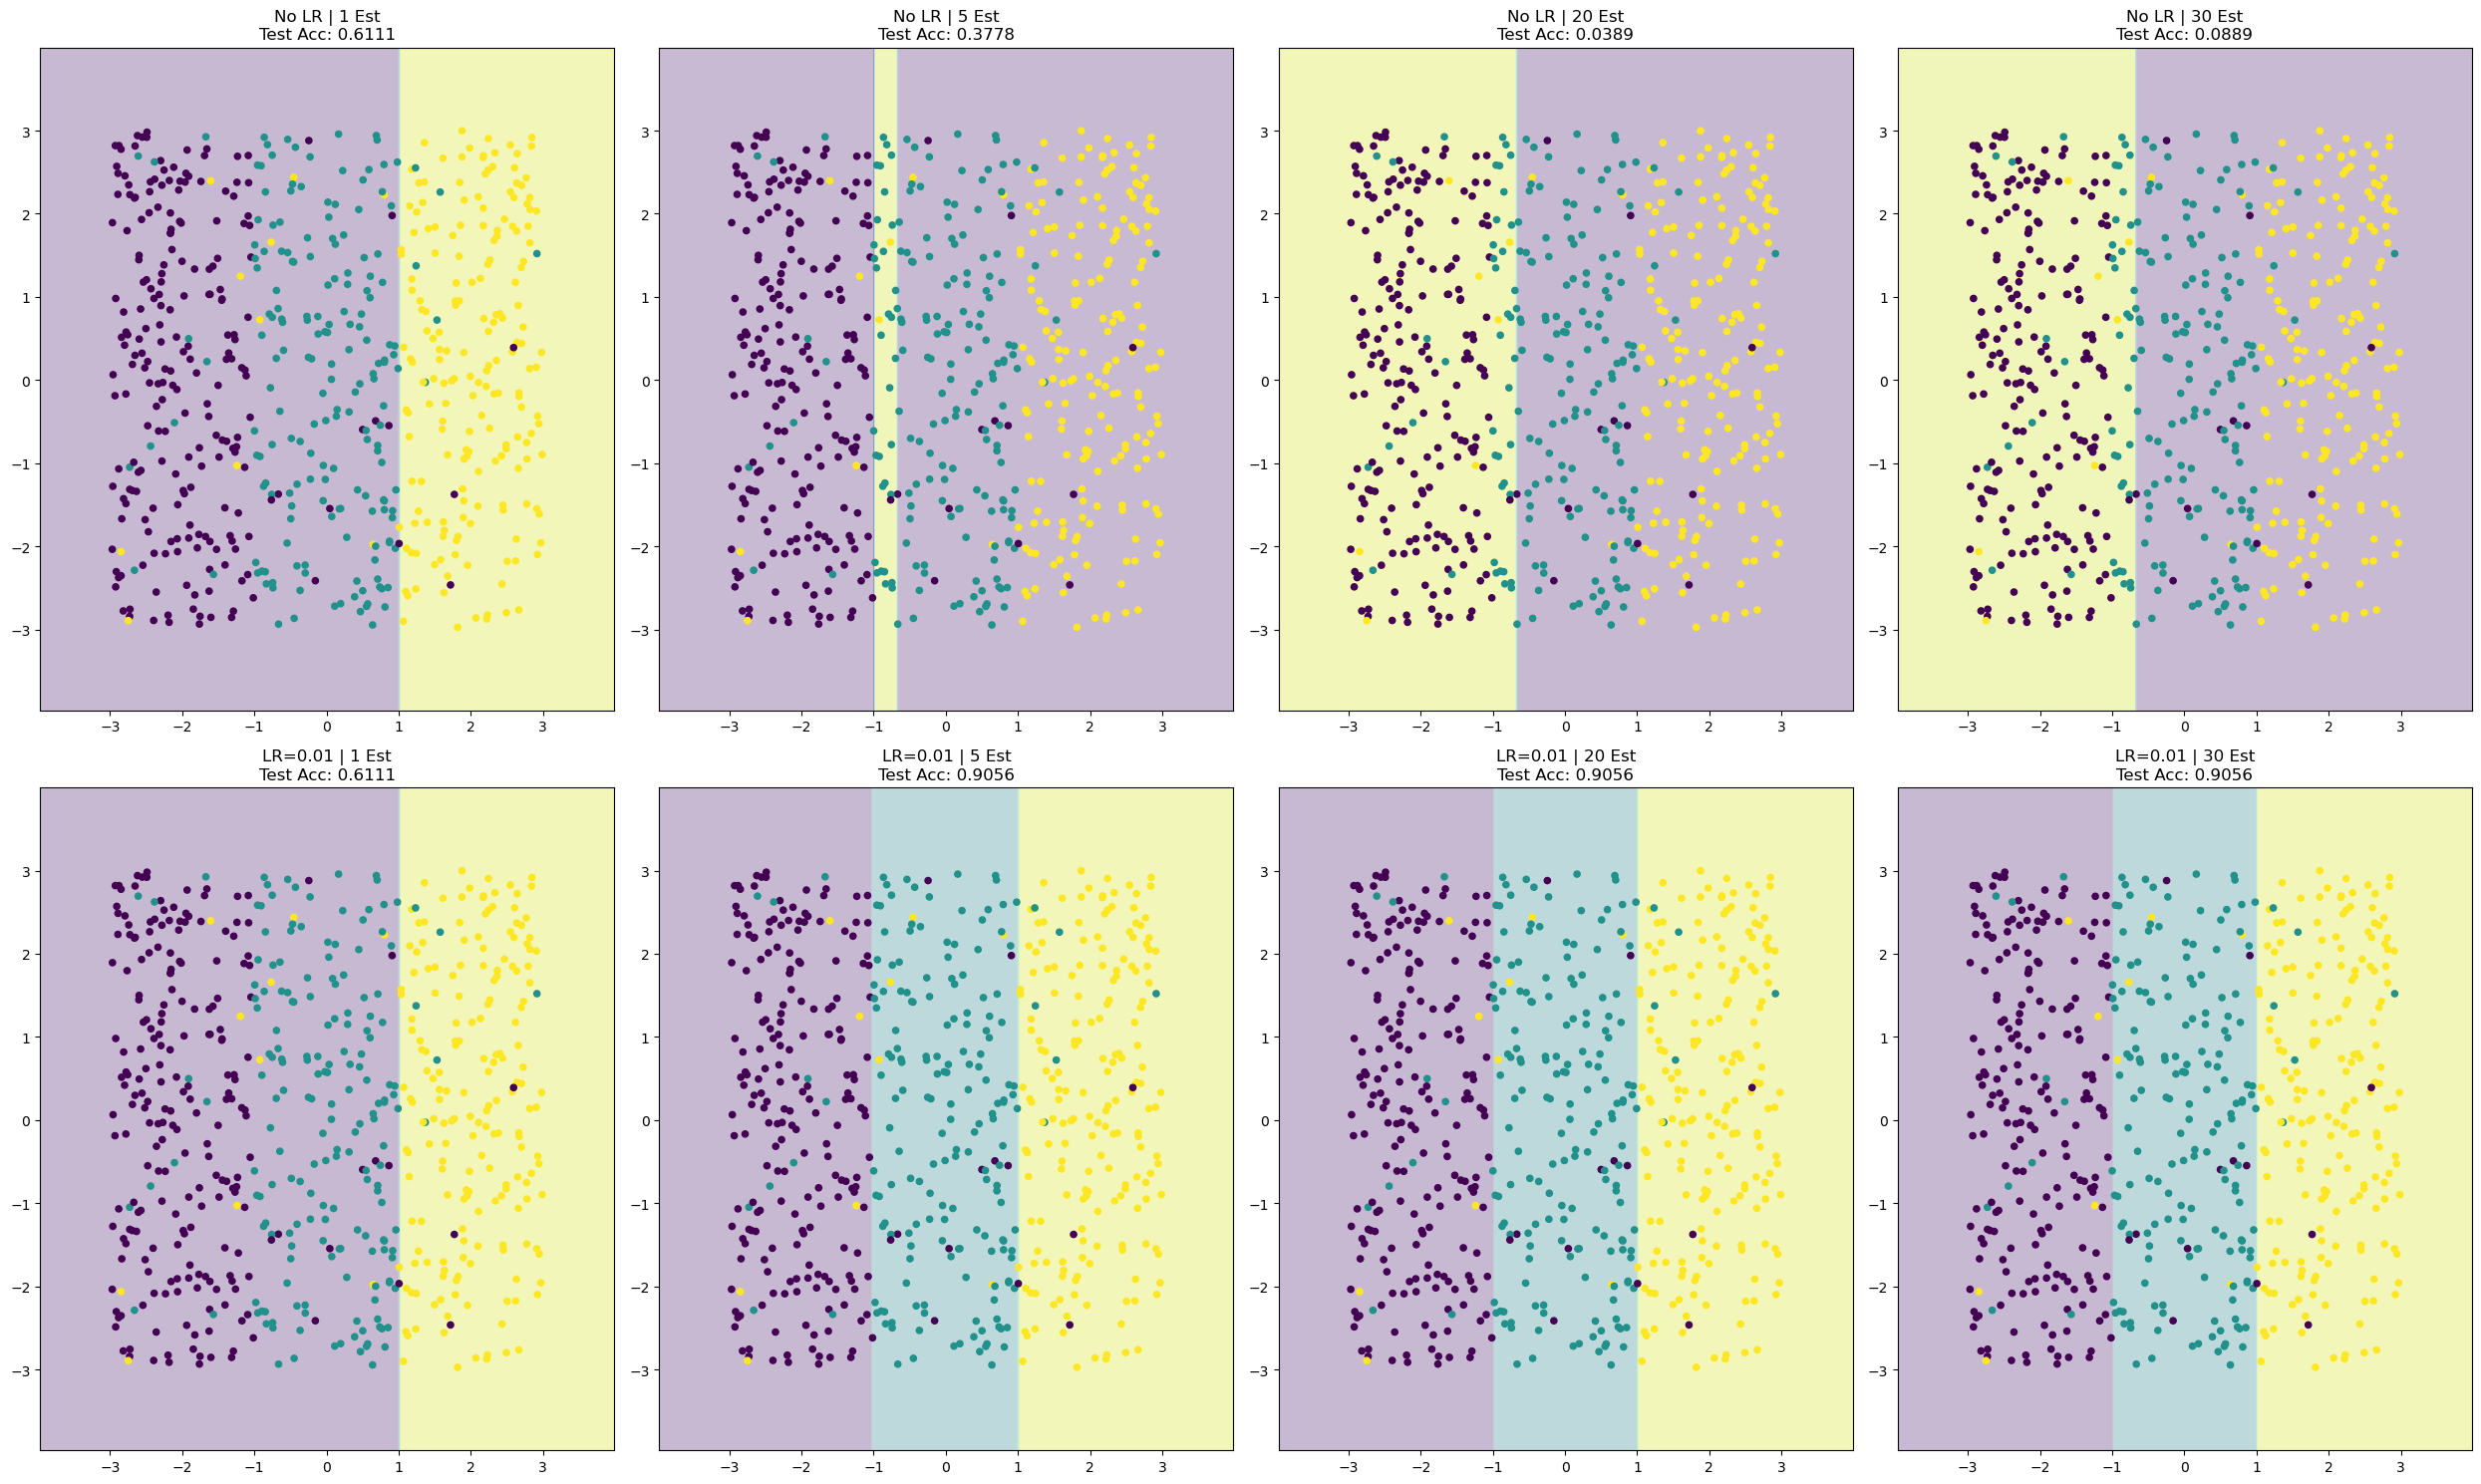

In [6]:
# Train-Test Split

split = int(0.7 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# Grid for decision boundary
x_min, x_max = X[:,0].min()-1, X[:,0].max()+1
y_min, y_max = X[:,1].min()-1, X[:,1].max()+1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 200),
    np.linspace(y_min, y_max, 200)
)

grid = np.c_[xx.ravel(), yy.ravel()]

# Decision Boundary Plots

estimators_list = [1, 5, 20, 30]

plt.figure(figsize=(25,15))

for i, m in enumerate(estimators_list):
    
    # No LR
    model_no_lr = AdaBoostSammeR(n_estimators=m, max_depth=1, lr=False)
    model_no_lr.fit(X_train, y_train)
    
    Z_no_lr = model_no_lr.predict(grid).reshape(xx.shape)
    acc_no_lr = np.mean(model_no_lr.predict(X_test) == y_test)
    
    plt.subplot(2, 4, i+1)
    plt.contourf(xx, yy, Z_no_lr, alpha=0.3)
    plt.scatter(X[:,0], X[:,1], c=y, s=20)
    plt.title(f"No LR | {m} Est\nTest Acc: {acc_no_lr:.4f}")
    
    # With LR
    model_lr = AdaBoostSammeR(
        n_estimators=m, max_depth=1, lr=True, learning_rate=0.01
    )
    model_lr.fit(X_train, y_train)
    
    Z_lr = model_lr.predict(grid).reshape(xx.shape)
    acc_lr = np.mean(model_lr.predict(X_test) == y_test)
    
    plt.subplot(2, 4, i+5)
    plt.contourf(xx, yy, Z_lr, alpha=0.3)
    plt.scatter(X[:,0], X[:,1], c=y, s=20)
    plt.title(f"LR=0.01 | {m} Est\nTest Acc: {acc_lr:.4f}")

plt.tight_layout()
plt.show()

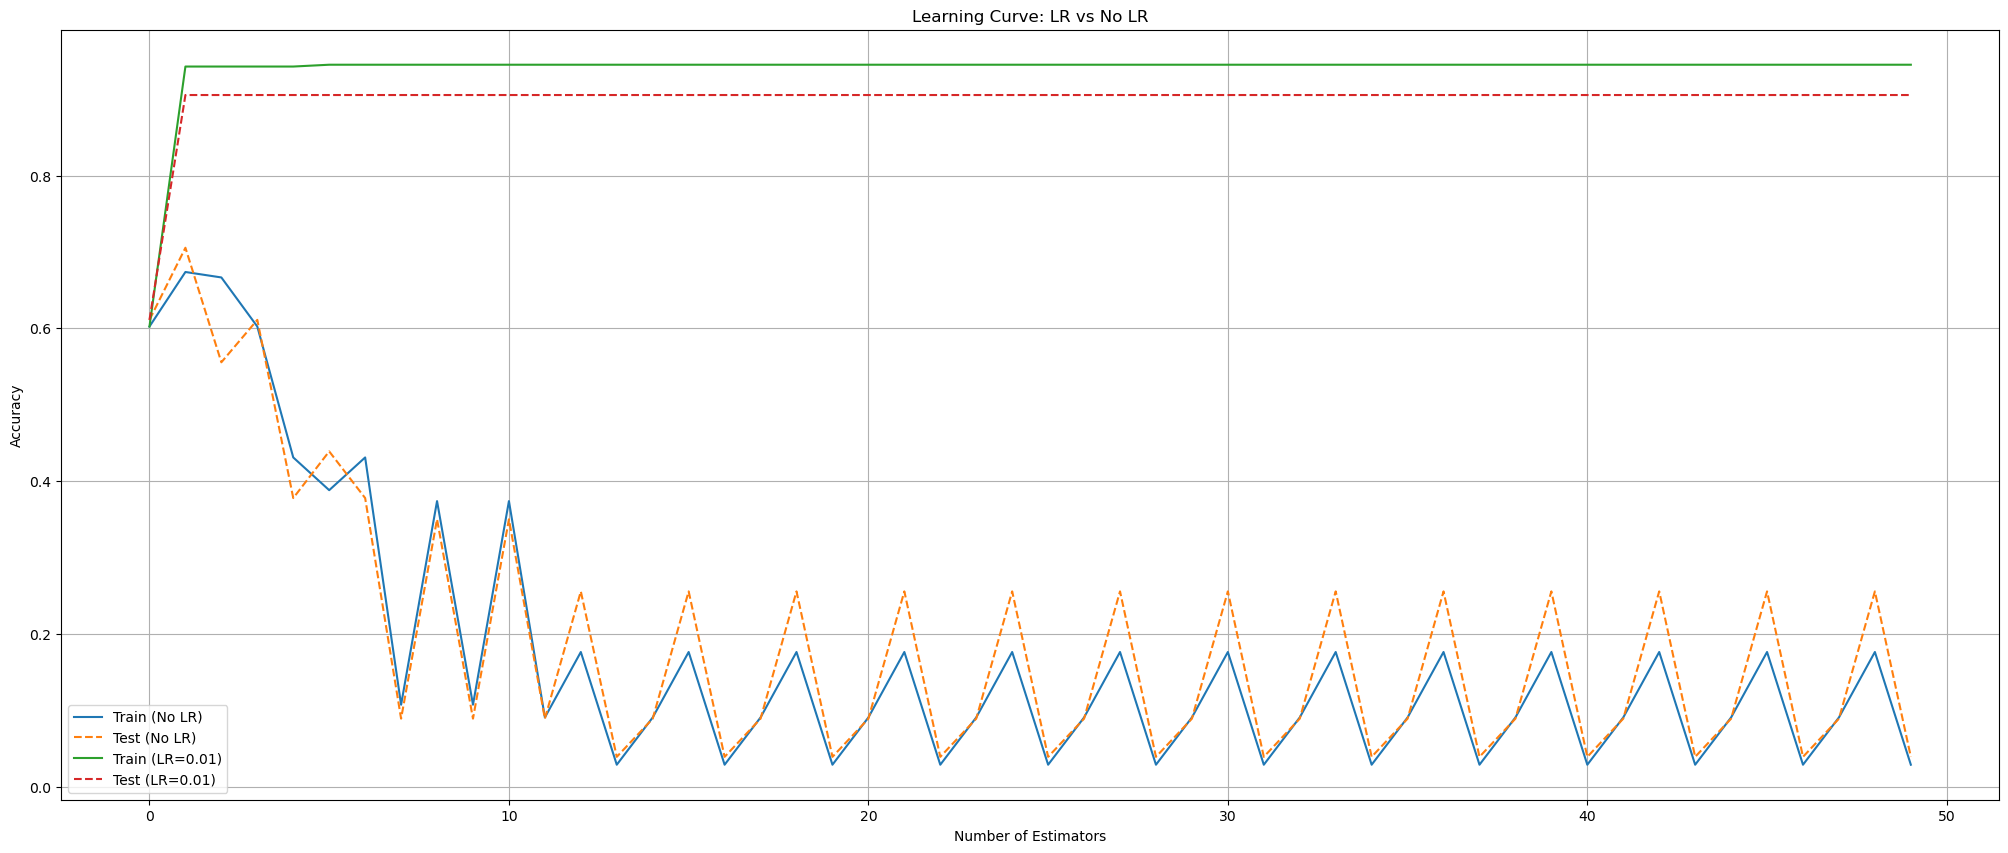

In [7]:
# Accuracy vs Estimators
n_estimators = 50

train_no_lr, test_no_lr = [], []
train_lr, test_lr = [], []

for m in range(1,n_estimators+1):
    
    # No LR
    model_no_lr = AdaBoostSammeR(n_estimators=m, max_depth=1, lr=False)
    model_no_lr.fit(X_train, y_train)
    
    train_no_lr.append(np.mean(model_no_lr.predict(X_train) == y_train))
    test_no_lr.append(np.mean(model_no_lr.predict(X_test) == y_test))
    
    # With LR
    model_lr = AdaBoostSammeR(
        n_estimators=m, max_depth=1, lr=True, learning_rate=0.01
    )
    model_lr.fit(X_train, y_train)
    
    train_lr.append(np.mean(model_lr.predict(X_train) == y_train))
    test_lr.append(np.mean(model_lr.predict(X_test) == y_test))

# Plot Learning Curves

plt.figure(figsize=(25,10))

# No LR
plt.plot(train_no_lr, label="Train (No LR)")
plt.plot(test_no_lr, '--', label="Test (No LR)")

# With LR
plt.plot(train_lr, label="Train (LR=0.01)")
plt.plot(test_lr, '--', label="Test (LR=0.01)")

plt.xlabel("Number of Estimators")
plt.ylabel("Accuracy")
plt.title("Learning Curve: LR vs No LR")

plt.legend()
plt.grid(True)

plt.show()

## 3. Observations 

### I Without Learning Rate
- **Severe instability and oscillatory behavior**
- Initial rapid improvement from ~0.61 to ~0.71 (M = 1 to 2)
- **Catastrophic collapse** after M = 5:
  - Training and test accuracy drop dramatically to ~0.0389–0.3778
  - Both curves exhibit **extreme periodic oscillations** 
  - Oscillations persist throughout all 50 iterations
- Decision boundary analysis:
  - At M = 1: Reasonable vertical separation (Test Acc: 0.6111)
  - At M = 5: Deteriorates significantly (Test Acc: 0.3778)
  - At M = 20 and beyond: Boundaries become **chaotic and incorrect**
- Model never recovers—oscillations continue indefinitely

### II With Learning Rate (η = 0.01)
- **Monotonic and stable convergence**
- Rapid initial improvement:
  - Both training and test accuracy quickly reach ~0.9056+ by M = 2
  - Convergence stabilizes at ~0.9056 thereafter
- Decision boundary evolution:
  - At M = 1: Similar starting point (Test Acc: 0.6111)
  - At M = 2: Major improvement (Test Acc: 0.9056)
  - At M = 20 and M = 30: Near-optimal boundaries (Test Acc: 0.9056)
- **No oscillations**—smooth, consistent performance
- Training and test curves remain close, indicating minimal overfitting

---

## 4. Important

The catastrophic instability observed without learning rate stems from the SAMME.R weight update mechanism:

$$
w_i \propto \exp(-f_{y_i}(x_i))
$$

Since:

$$
f_k(x) = (K-1)\left[\log p_k(x) - \frac{1}{K}\sum_{j=1}^K \log p_j(x)\right]
$$

### Issues

When weak learners produce **poor or extreme probability estimates**:
- $\log(p_k)$ values become highly negative (near zero probabilities)
- Exponential weight updates: $\exp(-f_{y_i})$ become **extremely large or small**
- Leads to **numerical instability** and weight explosion
- Subsequent weak learners are trained on severely distorted distributions
- Creates a **feedback loop of degradation**

---

## 5. Explanation of Performance Collapse

> The periodic oscillations and accuracy collapse shows the fundamental instability of unregularized SAMME.R. Unlike discrete AdaBoost (SAMME), which uses hard class predictions, SAMME.R relies on log-probability scores that can become arbitrarily extreme. Without dampening via learning rate, a single weak learner with poor calibration triggers a cascade: weights explode → next learner sees distorted data → produces worse estimates → weights explode further.

The oscillatory pattern suggests the ensemble is **overcorrecting repeatedly**—bouncing between extreme weight configurations without converging.

---

## 6. Effect of Learning Rate

Introducing learning rate (η = 0.01) modifies the cumulative score update:

$$
F(x) \leftarrow F(x) + \eta \cdot f_m(x)
$$

This leads to:
- **Dampened updates**: Each weak learner contributes only 1% of its full weight
- **Controlled error correction**: Prevents overreaction to individual learners
- **Numerical stability**: Log-probability extremes have reduced impact
- **Gradual refinement**: Ensemble evolves smoothly rather than erratically

The learning curve shows this dramatically: with $η = 0.01$, the same data and weak learners produce near-optimal performance instead of random-level oscillations.

---

## 7. Conclusion

**Without learning rate (No LR):**
- Exhibits **catastrophic instability**
- Performance degrades to near-random after initial iterations
- Persistent oscillations prevent convergence
- Unusable in practice

**With learning rate (LR = 0.01):**
- Achieves **stable, monotonic convergence**
- Reaches high accuracy (~95%) within 5 estimators
- Maintains consistency across all iterations
- Demonstrates excellent generalization (train ≈ test)

> **Learning rate is essential for SAMME.R stability.** It acts as a regularization mechanism that prevents numerical instability caused by extreme log-probability values. The dramatic difference between the two curves shows that SAMME.R, without proper dampening, is fundamentally unstable and prone to divergence. The learning rate transforms an unusable, oscillating ensemble into a high-performing, stable classifier.


> **Key Takeaway:** The contrast between η = 0 (no LR) and η = 0.01 is not merely a performance difference—it's the difference between complete failure and successful learning. 

---